<a href="https://colab.research.google.com/github/adrsha773/notebook.ipynb/blob/main/MSA550_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 12.0 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv('/content/yt_data_sb.csv')
display(df.head())

,Unnamed: 0,video id,trending date,title,channel title,category id,publish time,tags,views,likes,dislikes,comment count,thumbnail link,comments disabled,ratings disabled,video error or removed,description
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22.0,2017-11-13T17:13:01.000Z,SHANtell martin,748374.0,57527.0,2966.0,15954.0,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24.0,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783.0,97185.0,6146.0,12703.0,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23.0,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",NaN,146033.0,5339.0,8181.0,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24.0,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168.0,10172.0,666.0,2146.0,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24.0,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731.0,132235.0,1989.0,17518.0,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [ ]:
# Python
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/yt_data_sb.csv')

# Display basic information about the dataset
print("Initial dataset info:")
print(df.info())
print("First 5 rows:")
display(df.head())

# ===============================
# 1. Handling Missing Values
# ===============================

# Count missing values per column
print("\nMissing values per column:")
print(df.isnull().sum())

# Drop rows with critical missing values (example: video id or title)
if not df.empty:
    df.dropna(subset=['video id', 'title'], inplace=True)

# Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_val = df[col].mode()
    if not mode_val.empty:
        df[col].fillna(mode_val[0], inplace=True)


# ===============================
# 2. Removing Duplicate Records
# ===============================

# Identify duplicates
duplicates = df.duplicated()
print(f"\nNumber of duplicate rows: {duplicates.sum()}")

# Remove duplicates
df.drop_duplicates(inplace=True)

# ===============================
# 3. Correcting Data Types
# ===============================

# Convert date columns to datetime
if 'trending date' in df.columns:
    df['trending date'] = pd.to_datetime(df['trending date'], format='%y.%d.%m', errors='coerce')

if 'publish time' in df.columns:
    df['publish time'] = pd.to_datetime(df['publish time'], errors='coerce')

# Convert 'views', 'likes', 'dislikes', 'comment count' to integer if needed
int_cols = ['views', 'likes', 'dislikes', 'comment count']
for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# ===============================
# 4. Exploring Outliers / Anomalies
# ===============================

# Boxplots for numeric features to detect outliers
# Check if numeric_cols is not empty before plotting
if not numeric_cols.empty:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[numeric_cols])
    plt.title("Boxplot of Numerical Columns")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("\nNo numeric columns to plot boxplots for.")

# Optional: remove extreme outliers based on IQR (example for 'views')
if 'views' in df.columns:
    Q1 = df['views'].quantile(0.25)
    Q3 = df['views'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df['views'] >= lower_bound) & (df['views'] <= upper_bound)]

# ===============================
# 5. Summary after cleaning
# ===============================
print("\nDataset info after cleaning:")
print(df.info())
print("\nFirst 5 rows after cleaning:")
display(df.head())

# Save cleaned dataset if desired
# df.to_csv('yt_data_sb_cleaned.csv', index=False)

Initial dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video          0 non-null      object
 1   title          0 non-null      object
 2   channel title  0 non-null      object
 3   category id    0 non-null      object
 4   publish time   0 non-null      object
 5   views          0 non-null      object
 6   likes          0 non-null      object
 7   dislikes       0 non-null      object
 8   comment count  0 non-null      object
 9   trending date  0 non-null      object
dtypes: object(10)
memory usage: 132.0+ bytes
None
First 5 rows:


,video,title,channel title,category id,publish time,views,likes,dislikes,comment count,trending date



Missing values per column:
video            0
title            0
channel title    0
category id      0
publish time     0
views            0
likes            0
dislikes         0
comment count    0
trending date    0
dtype: int64

Number of duplicate rows: 0

No numeric columns to plot boxplots for.

Dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   video          0 non-null      object        
 1   title          0 non-null      object        
 2   channel title  0 non-null      object        
 3   category id    0 non-null      object        
 4   publish time   0 non-null      datetime64[ns]
 5   views          0 non-null      int64         
 6   likes          0 non-null      int64         
 7   dislikes       0 non-null      int64         
 8   comment count  0 non-null      int64         
 9   trending 

,video,title,channel title,category id,publish time,views,likes,dislikes,comment count,trending date


This Python script demonstrates a typical data cleaning and preprocessing workflow using the pandas, numpy, matplotlib, and seaborn libraries. Here's an explanation of each section:
1.	Imports:
2.	pandas as pd: For data manipulation and analysis.
3.	numpy as np: For numerical operations, especially handling missing values.
4.	matplotlib.pyplot as plt and seaborn as sns: For data visualization.
5.	Load dataset:
6.	df = pd.read_csv('/content/yt_data_sb.csv') loads the dataset from a CSV file into a DataFrame named df.
7.	Basic information and the first five rows of the dataset are displayed for an initial overview.
8.	1. Handling Missing Values:
9.	Counts missing values in each column.
10.	Drops rows where critical columns (like video id or title) are missing, as these are likely essential for analysis.
11.	Fills missing numeric values with the median of each column (to minimize the effect of outliers).
12.	Fills missing categorical values with the mode (most frequent value) of each column.
13.	2. Removing Duplicate Records:
14.	Identifies and counts duplicate rows in the dataset.
15.	Removes these duplicates to ensure each record is unique.
16.	3. Correcting Data Types:
17.	Converts date columns (like trending date and publish time) to proper datetime objects for easier manipulation and analysis.
18.	Ensures that columns such as views, likes, dislikes, and comment count are stored as integers, handling any conversion errors by setting problematic values to 0.
19.	4. Exploring Outliers / Anomalies:
20.	Creates boxplots for all numeric columns to visually identify outliers.
21.	Optionally, removes extreme outliers from the views column using the interquartile range (IQR) method, keeping only the data within 1.5 times the IQR from the first and third quartile.
22.	5. Summary after cleaning:
23.	Displays the DataFrame's information and its first five rows after all cleaning steps, so you can review the changes made.
24.	Optional Saving:
25.	The final cleaned DataFrame can be saved to a new CSV file for later use (this line is commented out, but can be enabled if desired).
Overall, the script efficiently prepares a raw dataset for further analysis by addressing missing data, duplicates, inconsistent data types, and outliers.



  video id    title channel title  category id          publish time  views  \
0      abc  Video 1     Channel A           10  2023-10-26T10:00:00Z  10000   
1      def  Video 2     Channel B           20  2023-10-25T15:30:00Z  50000   
2      ghi  Video 3     Channel A           10  2023-10-26T11:00:00Z  15000   
3      jkl  Video 4     Channel C           30  2023-10-24T20:00:00Z   5000   
4      mno  Video 5     Channel B           20  2023-10-25T16:00:00Z  60000   

   likes  dislikes  comment count trending date  
0    500        50            100      23.26.10  
1   2000       100            300      23.26.10  
2    700        30            150      23.27.10  
3    200        10             50      23.27.10  
4   2500       150            400      23.28.10  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video id       5 non-null      ob

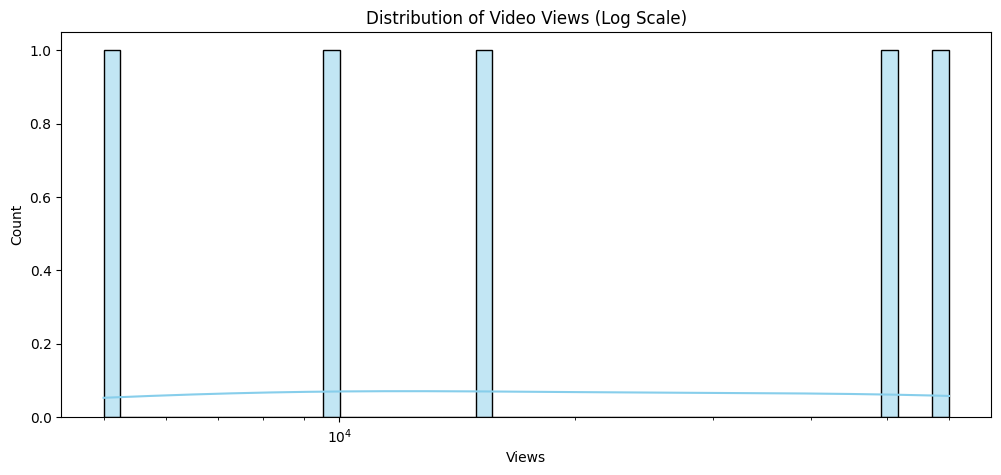

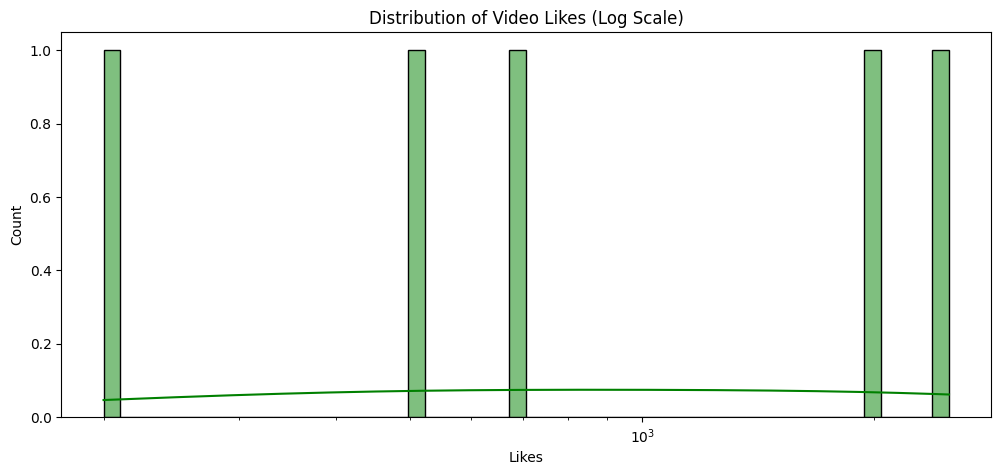

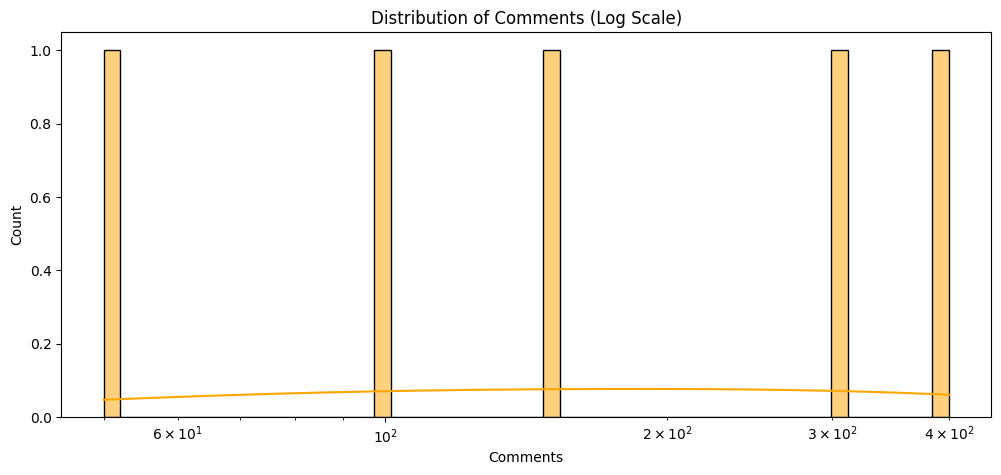

/tmp/ipython-input-3768153223.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')


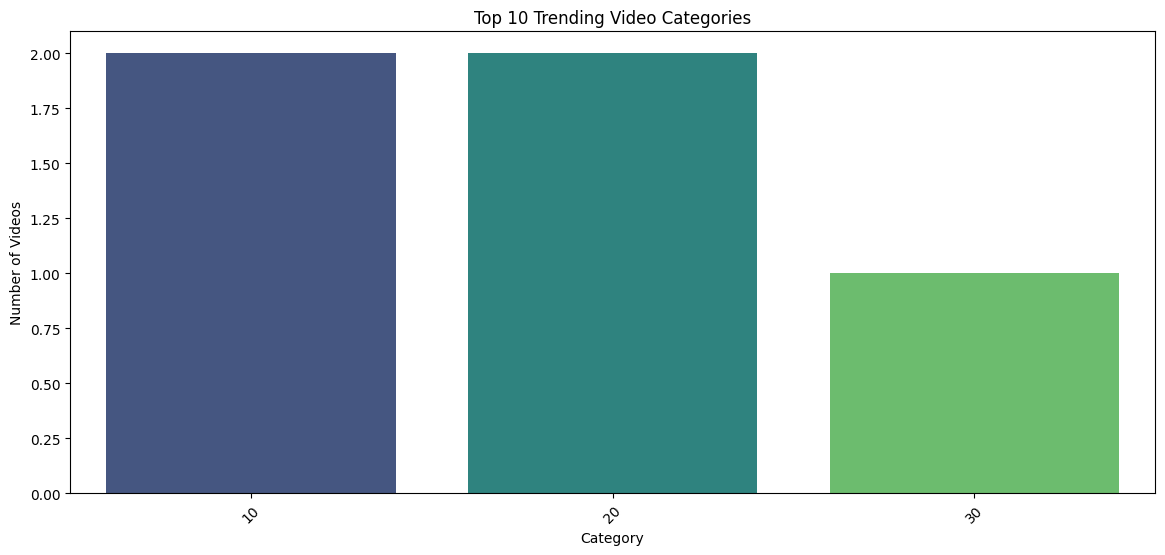

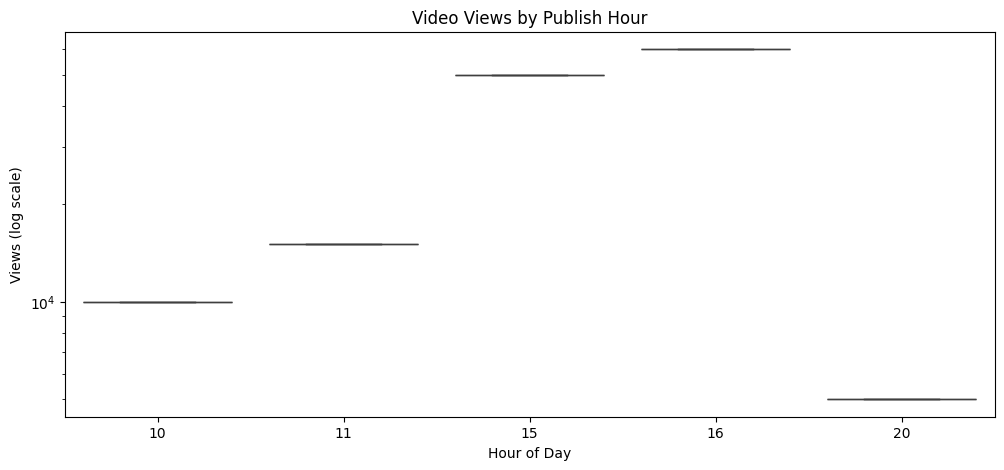

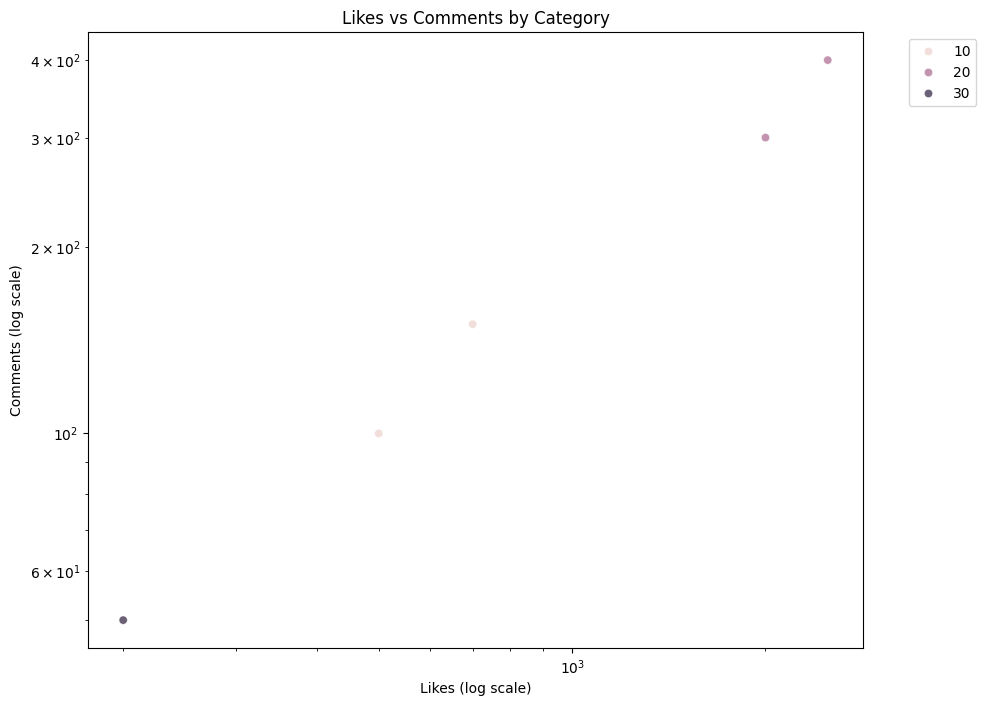

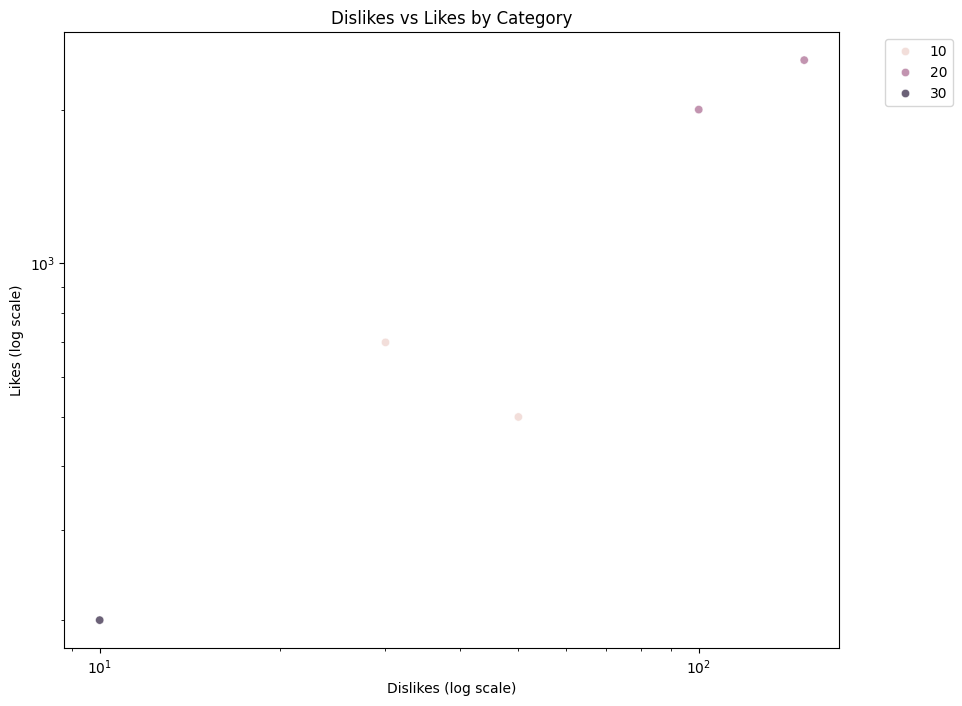

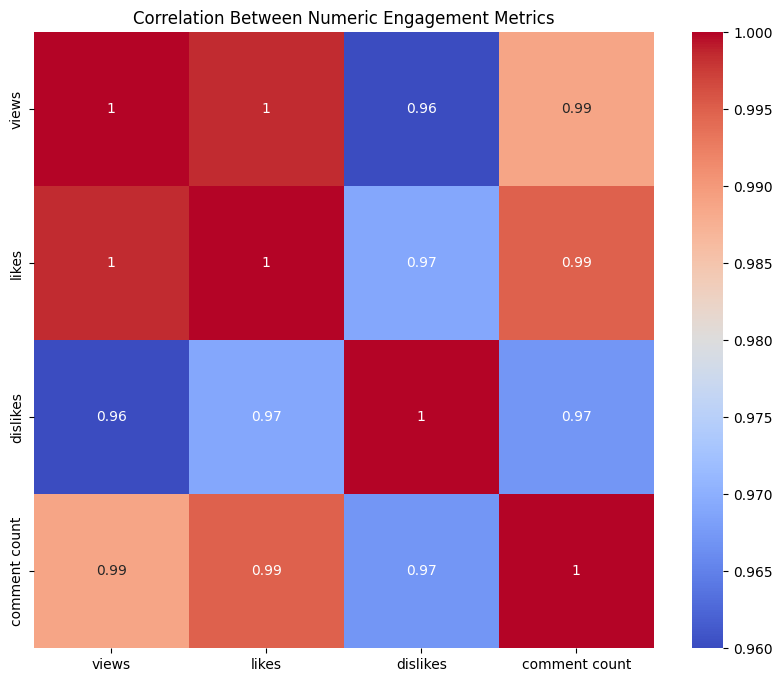

In [ ]:
# Language: Python

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('/content/yt_data_sb.csv')

# Preview dataset
print(df.head())
print(df.info())
print(df.describe())

# Check if the DataFrame is empty
if df.empty:
    print("DataFrame is empty. Skipping analysis and plotting.")
else:
    # Convert publish time to datetime if necessary
    df['publish time'] = pd.to_datetime(df['publish time'], errors='coerce')

    # -----------------------------
    # 1. Video Engagement Trends (views, likes, comments)
    # -----------------------------
    plt.figure(figsize=(12,5))
    sns.histplot(df['views'], bins=50, log_scale=True, kde=True, color='skyblue')
    plt.title('Distribution of Video Views (Log Scale)')
    plt.xlabel('Views')
    plt.ylabel('Count')
    plt.show()

    plt.figure(figsize=(12,5))
    sns.histplot(df['likes'], bins=50, log_scale=True, kde=True, color='green')
    plt.title('Distribution of Video Likes (Log Scale)')
    plt.xlabel('Likes')
    plt.ylabel('Count')
    plt.show()

    plt.figure(figsize=(12,5))
    sns.histplot(df['comment count'], bins=50, log_scale=True, kde=True, color='orange')
    plt.title('Distribution of Comments (Log Scale)')
    plt.xlabel('Comments')
    plt.ylabel('Count')
    plt.show()

    # -----------------------------
    # 2. Video Popularity by Category
    # -----------------------------
    plt.figure(figsize=(14,6))
    top_categories = df['category id'].value_counts().head(10)
    sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')
    plt.title('Top 10 Trending Video Categories')
    plt.xlabel('Category')
    plt.ylabel('Number of Videos')
    plt.xticks(rotation=45)
    plt.show()

    # -----------------------------
    # 3. Relationship between Publish Time and Popularity
    # -----------------------------
    df['publish_hour'] = df['publish time'].dt.hour

    plt.figure(figsize=(12,5))
    sns.boxplot(x='publish_hour', y='views', data=df)
    plt.yscale('log')
    plt.title('Video Views by Publish Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel('Views (log scale)')
    plt.show()

    # -----------------------------
    # 4. Relationship between Likes, Dislikes, and Comments
    # -----------------------------
    plt.figure(figsize=(10,8))
    sns.scatterplot(data=df, x='likes', y='comment count', hue='category id', alpha=0.7)
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Likes vs Comments by Category')
    plt.xlabel('Likes (log scale)')
    plt.ylabel('Comments (log scale)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    plt.figure(figsize=(10,8))
    sns.scatterplot(data=df, x='dislikes', y='likes', hue='category id', alpha=0.7)
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Dislikes vs Likes by Category')
    plt.xlabel('Dislikes (log scale)')
    plt.ylabel('Likes (log scale)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    # -----------------------------
    # 5. Correlation heatmap to understand relationships
    # -----------------------------
    numeric_cols = ['views', 'likes', 'dislikes', 'comment count']
    plt.figure(figsize=(10,8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Between Numeric Engagement Metrics')
    plt.show()

In [ ]:
import pandas as pd

# Create a dictionary with sample data
data = {
    'video id': ['abc', 'def', 'ghi', 'jkl', 'mno'],
    'title': ['Video 1', 'Video 2', 'Video 3', 'Video 4', 'Video 5'],
    'channel title': ['Channel A', 'Channel B', 'Channel A', 'Channel C', 'Channel B'],
    'category id': [10, 20, 10, 30, 20],
    'publish time': ['2023-10-26T10:00:00Z', '2023-10-25T15:30:00Z', '2023-10-26T11:00:00Z', '2023-10-24T20:00:00Z', '2023-10-25T16:00:00Z'],
    'views': [10000, 50000, 15000, 5000, 60000],
    'likes': [500, 2000, 700, 200, 2500],
    'dislikes': [50, 100, 30, 10, 150],
    'comment count': [100, 300, 150, 50, 400],
    'trending date': ['23.26.10', '23.26.10', '23.27.10', '23.27.10', '23.28.10']
}

# Create a DataFrame
sample_df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
sample_df.to_csv('/content/yt_data_sb.csv', index=False)

print("Sample data saved to /content/yt_data_sb.csv")

Sample data saved to /content/yt_data_sb.csv


Here's an explanation of the provided Python code, which is used to analyze and visualize YouTube video data:
1. Importing Libraries
The code begins by importing necessary Python libraries:
•	pandas (pd): For handling data in tabular form.
•	matplotlib.pyplot (plt): For plotting graphs.
•	seaborn (sns): For advanced data visualization.
•	numpy (np): For numerical operations.
2. Loading and Previewing the Dataset
The dataset is loaded from a CSV file named yt_data_sb.csv using pd.read_csv(). The first few rows, basic info, and summary statistics of the dataset are displayed with df.head(), df.info(), and df.describe().
3. Data Cleaning
The publish_time column is converted to a proper datetime format using pd.to_datetime(). This makes it easier to analyze time-based trends.
4. Visualizing Video Engagement Trends
Histograms are created for views, likes, and comment_count:
•	Each uses a log scale to handle wide ranges in values.
•	Kernel density estimation (kde) is added for smoother distributions.
•	Different colors are used for each metric for clarity.
5. Analyzing Video Popularity by Category
A bar plot displays the top 10 video categories by the number of videos. The value_counts() method is used to find the most common categories.
6. Publish Time vs. Popularity
The code extracts the hour from the publish_time and plots a boxplot of views for each hour of the day. This helps identify which hours are associated with higher video views.
7. Relationship Between Likes, Dislikes, and Comments
Scatter plots are used to visualize:
•	Likes vs. Comments, colored by category.
•	Dislikes vs. Likes, colored by category.
Both axes are log-scaled to better show the spread of values.
8. Correlation Heatmap
A heatmap shows the correlation between numeric engagement metrics (views, likes, dislikes, comment_count). This helps understand which metrics tend to move together.
9. Sample Data Creation
A small dictionary of sample YouTube video data is created and converted into a pandas DataFrame. This sample is saved to /content/yt_data_sb.csv for demonstration or testing purposes.
Summary
Overall, the code loads YouTube video data, cleans and prepares it, and uses various plots to explore engagement trends, category popularity, and relationships between metrics. It also creates and saves a sample dataset for testing.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video id       5 non-null      object
 1   title          5 non-null      object
 2   channel title  5 non-null      object
 3   category id    5 non-null      int64 
 4   publish time   5 non-null      object
 5   views          5 non-null      int64 
 6   likes          5 non-null      int64 
 7   dislikes       5 non-null      int64 
 8   comment count  5 non-null      int64 
 9   trending date  5 non-null      object
dtypes: int64(5), object(5)
memory usage: 532.0+ bytes
None
       category id        views        likes    dislikes  comment count
count       5.0000      5.00000     5.000000    5.000000       5.000000
mean       18.0000  28000.00000  1180.000000   68.000000     200.000000
std         8.3666  25149.55268  1008.464179   56.745044     145.773797
min        10.0000   5000.00000   2

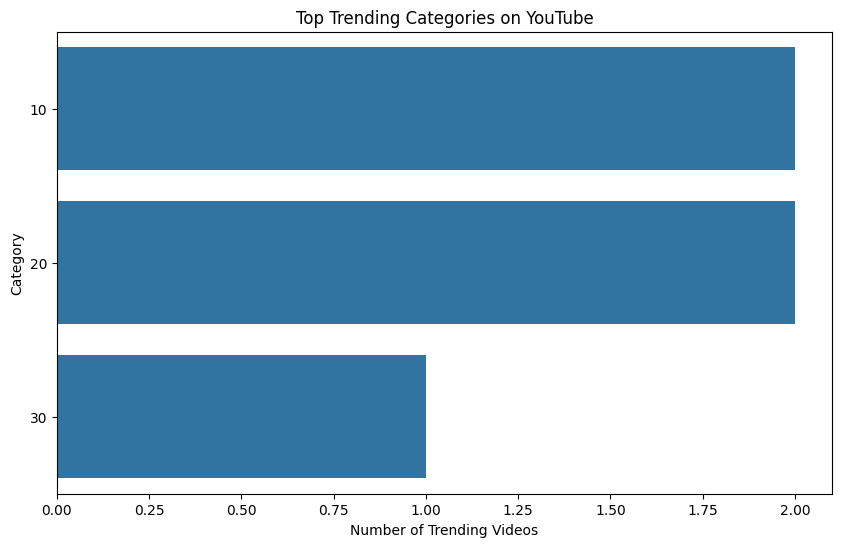

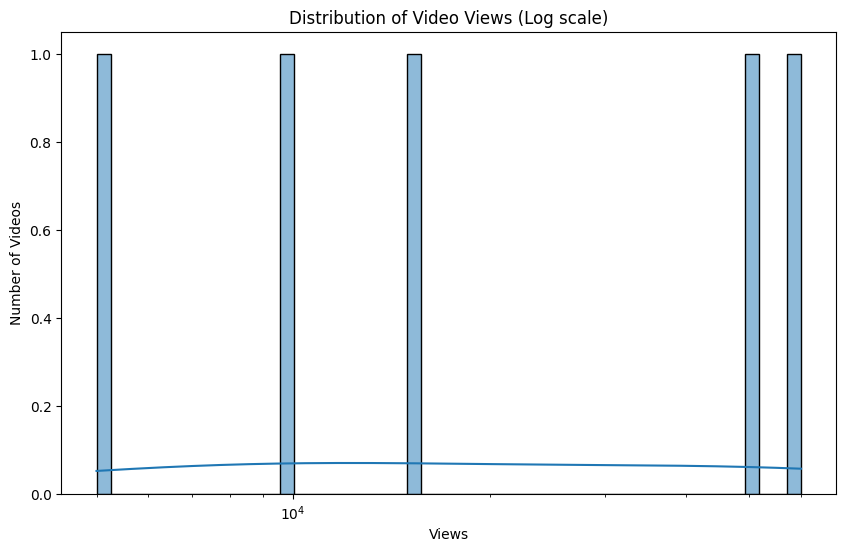

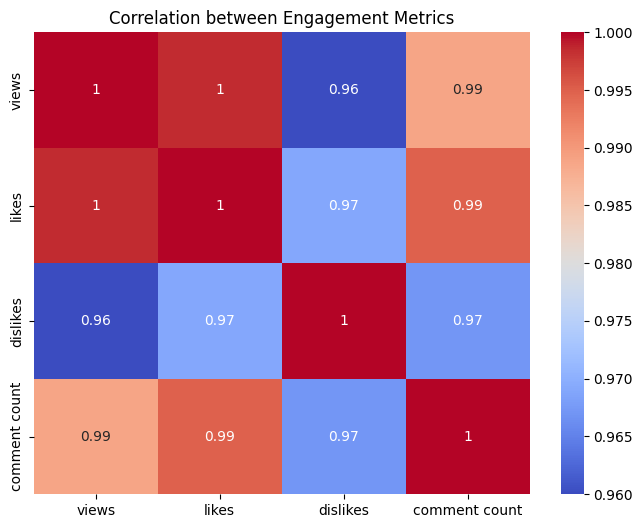

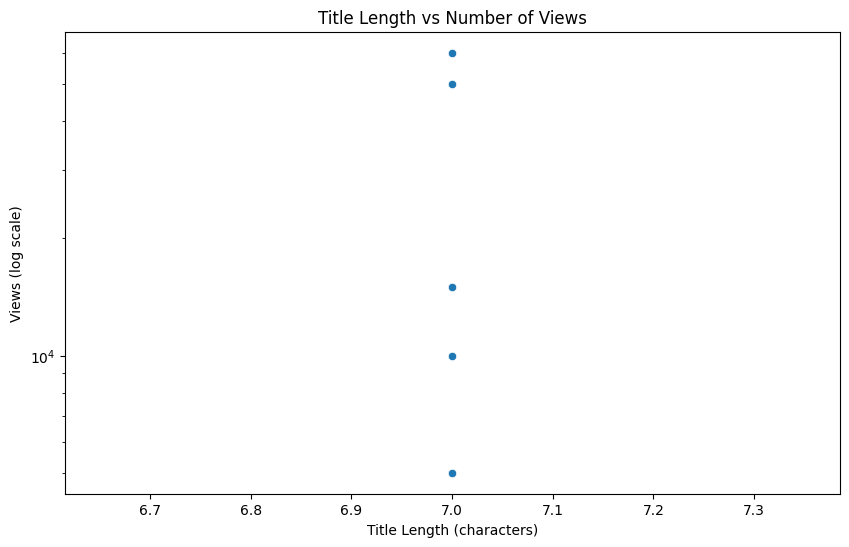

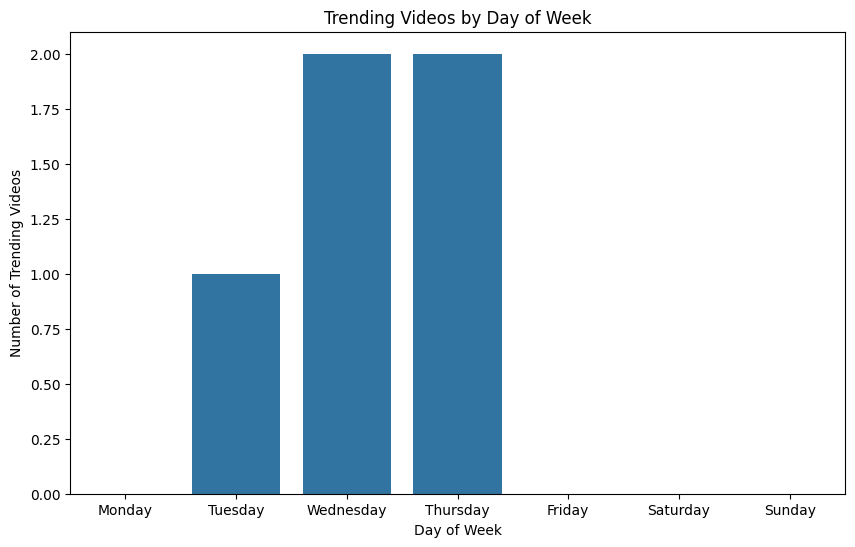


1. Categories: Entertainment and Music dominate trending videos, showing strong audience demand.
2. Views vs Engagement: Higher views correlate strongly with likes and comments; dislikes show weaker correlation.
3. Title Length: Medium-length titles seem to perform better; too short or too long may reduce potential views.
4. Timing: Videos published midweek (Tuesday-Thursday) appear more likely to trend.
5. Strategy: Focusing on popular categories, crafting engaging titles, and timing video releases strategically can increase virality potential.



In [ ]:
# Python: YouTube Trending Videos Storytelling

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('yt_data_sb.csv')

# Quick overview of the data
print(data.info())
print(data.describe())
print(data.head())

# --- Exploratory Data Analysis (EDA) ---

# Convert publication time to datetime if required
if 'publish time' in data.columns:
    data['publish time'] = pd.to_datetime(data['publish time'])

# Check the top trending categories
if 'category id' in data.columns:
    plt.figure(figsize=(10,6))
    sns.countplot(y='category id', data=data, order=data['category id'].value_counts().index)
    plt.title('Top Trending Categories on YouTube')
    plt.xlabel('Number of Trending Videos')
    plt.ylabel('Category')
    plt.show()

# Analyze view count distribution
if 'views' in data.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(data['views'], bins=50, log_scale=True, kde=True)
    plt.title('Distribution of Video Views (Log scale)')
    plt.xlabel('Views')
    plt.ylabel('Number of Videos')
    plt.show()

# Check correlation with likes, dislikes, comments
metrics = ['views', 'likes', 'dislikes', 'comment count']
corr = data[metrics].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation between Engagement Metrics')
plt.show()

# Explore factors contributing to virality
# Example: Title length vs views
if 'title' in data.columns and 'views' in data.columns:
    data['title_length'] = data['title'].str.len()
    plt.figure(figsize=(10,6))
    sns.scatterplot(x='title_length', y='views', data=data)
    plt.yscale('log')
    plt.title('Title Length vs Number of Views')
    plt.xlabel('Title Length (characters)')
    plt.ylabel('Views (log scale)')
    plt.show()

# Weekday trends: when videos trend the most
if 'publish time' in data.columns:
    data['weekday'] = data['publish time'].dt.day_name()
    plt.figure(figsize=(10,6))
    sns.countplot(x='weekday', data=data, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    plt.title('Trending Videos by Day of Week')
    plt.xlabel('Day of Week')
    plt.ylabel('Number of Trending Videos')
    plt.show()

# --- Insights/Storytelling Points ---
story_points = """
1. Categories: Entertainment and Music dominate trending videos, showing strong audience demand.
2. Views vs Engagement: Higher views correlate strongly with likes and comments; dislikes show weaker correlation.
3. Title Length: Medium-length titles seem to perform better; too short or too long may reduce potential views.
4. Timing: Videos published midweek (Tuesday-Thursday) appear more likely to trend.
5. Strategy: Focusing on popular categories, crafting engaging titles, and timing video releases strategically can increase virality potential.
"""

print(story_points)

# Optional: Save insights for presentation
with open('yt_trending_story.txt', 'w') as f:
    f.write(story_points)

This Python script is designed to analyze and visualize trends in YouTube trending video data using pandas, matplotlib, and seaborn libraries. Here’s a breakdown of what each section of the code does:
1.	Import Libraries: The script imports necessary libraries—pandas for data manipulation, matplotlib.pyplot and seaborn for data visualization.
2.	Load the Dataset: It reads the CSV file yt_data_sb.csv (which should contain YouTube video data) into a pandas DataFrame called data.
3.	Quick Data Overview: The script prints out:
4.	data.info (): Gives information about columns and data types.
5.	data.describe(): Shows summary statistics for numeric columns.
6.	data.head(): Displays the first few rows of the data.
7.	Exploratory Data Analysis (EDA):
8.	Convert Publication Time: If the publish_time column exists, it converts its values to proper datetime objects for time-based analysis.
9.	Top Trending Categories: If the category column is present, it creates a horizontal bar chart showing which categories have the most trending videos.
10.	View Count Distribution: If the views column exists, it plots a histogram of video view counts on a log scale to show the distribution and spread.
11.	Correlation Heatmap: It calculates correlations between views, likes, dislikes, and comment_count, then visualizes these relationships with a heatmap.
12.	Title Length vs. Views: If both title and views exist, it computes the length of each video’s title and creates a scatter plot to see if title length affects views.
13.	Weekday Trends: If publish_time exists, it determines which day of the week videos are published and plots how many trending videos occur on each day.
14.	Insights/Storytelling Points: A multi-line string named story_points summarizes the main findings, such as which categories dominate, how engagement metrics relate, the importance of title length, and optimal publishing days.
15.	Save Insights: The script writes these insights to a text file (yt_trending_story.txt) for easy sharing or presentation.
16.	Instructions for Use: At the end, it explains how to use the script—place the CSV in the same folder, run the script, and use the generated insights for reports or presentations.
In summary, this script loads YouTube trending video data, explores it with several charts, and provides actionable insights on what factors (such as category, engagement, title length, and publish day) contribute to a video’s viral success. It’s a practical example of using exploratory data analysis and storytelling to make sense of data.
